# 🚦 Traffic Signs Recognition using CNN
## Objective
Build a Convolutional Neural Network to classify traffic sign images into 43 categories (stop, yield, speed limits, etc.) using the GTSRB dataset.

## Tech Stack
- TensorFlow/Keras for CNN
- OpenCV for image preprocessing
- scikit-learn for evaluation

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os
import random
import tensorflow as tf

from tensorflow.keras import models, layers
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

np.random.seed(42)
os.makedirs('outputs', exist_ok=True)
os.makedirs('models', exist_ok=True)

print("✅ Libraries imported successfully!")
print(f"TensorFlow Version: {tf.__version__}")

✅ Libraries imported successfully!
TensorFlow Version: 2.16.2


In [13]:
def load_dataset(data_dir, img_size=32):
    images = []
    labels = []
    
    for i in range(43):
        class_dir = os.path.join(data_dir, str(i))
        if not os.path.exists(class_dir):
            continue
            
        for img_name in os.listdir(class_dir):
            if img_name.startswith('.'):
                continue
            img_path = os.path.join(class_dir, img_name)
            img = cv2.imread(img_path)
            if img is not None:
                img = cv2.resize(img, (img_size, img_size))
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                images.append(img)
                labels.append(i)
                
        if i % 5 == 0 or i == 42:
            print(f"Loaded class {i}/43")
            
    X = np.array(images)
    y = np.array(labels)
    return X, y

X, y = load_dataset('data/Train')

print(f"Total images loaded: {X.shape[0]}")
print(f"Image shape: {X.shape[1:]}")
print(f"Number of classes: {len(np.unique(y))}")
print(f"Labels array shape: {y.shape}")

Loaded class 0/43
Loaded class 5/43
Loaded class 10/43
Loaded class 15/43
Loaded class 20/43
Loaded class 25/43
Loaded class 30/43
Loaded class 35/43
Loaded class 40/43
Loaded class 42/43
Total images loaded: 39209
Image shape: (32, 32, 3)
Number of classes: 43
Labels array shape: (39209,)


## 📊 Step 2: Dataset Exploration & Class Distribution

Before training, we explore the dataset to check for class imbalance and visually inspect sample images from each category.

In [14]:
class_names = {
    0: 'Speed limit (20km/h)', 1: 'Speed limit (30km/h)',
    2: 'Speed limit (50km/h)', 3: 'Speed limit (60km/h)',
    4: 'Speed limit (70km/h)', 5: 'Speed limit (80km/h)',
    6: 'End of speed limit (80km/h)', 7: 'Speed limit (100km/h)',
    8: 'Speed limit (120km/h)', 9: 'No passing',
    10: 'No passing veh over 3.5 tons', 11: 'Right-of-way at intersection',
    12: 'Priority road', 13: 'Yield', 14: 'Stop',
    15: 'No vehicles', 16: 'Veh > 3.5 tons prohibited',
    17: 'No entry', 18: 'General caution',
    19: 'Dangerous curve left', 20: 'Dangerous curve right',
    21: 'Double curve', 22: 'Bumpy road', 23: 'Slippery road',
    24: 'Road narrows on the right', 25: 'Road work',
    26: 'Traffic signals', 27: 'Pedestrians', 28: 'Children crossing',
    29: 'Bicycles crossing', 30: 'Beware of ice/snow',
    31: 'Wild animals crossing', 32: 'End speed + passing limits',
    33: 'Turn right ahead', 34: 'Turn left ahead', 35: 'Ahead only',
    36: 'Go straight or right', 37: 'Go straight or left',
    38: 'Keep right', 39: 'Keep left', 40: 'Roundabout mandatory',
    41: 'End of no passing', 42: 'End no passing veh > 3.5 tons'
}

 Class                    Class_Name  Count
     2          Speed limit (50km/h)   2250
     1          Speed limit (30km/h)   2220
    13                         Yield   2160
    12                 Priority road   2100
    38                    Keep right   2070
    10  No passing veh over 3.5 tons   2010
     4          Speed limit (70km/h)   1980
     5          Speed limit (80km/h)   1860
    25                     Road work   1500
     9                    No passing   1470
     7         Speed limit (100km/h)   1440
     3          Speed limit (60km/h)   1410
     8         Speed limit (120km/h)   1410
    11  Right-of-way at intersection   1320
    35                    Ahead only   1200
    18               General caution   1200
    17                      No entry   1110
    31         Wild animals crossing    780
    14                          Stop    780
    33              Turn right ahead    689
    15                   No vehicles    630
    26               Traffic sig

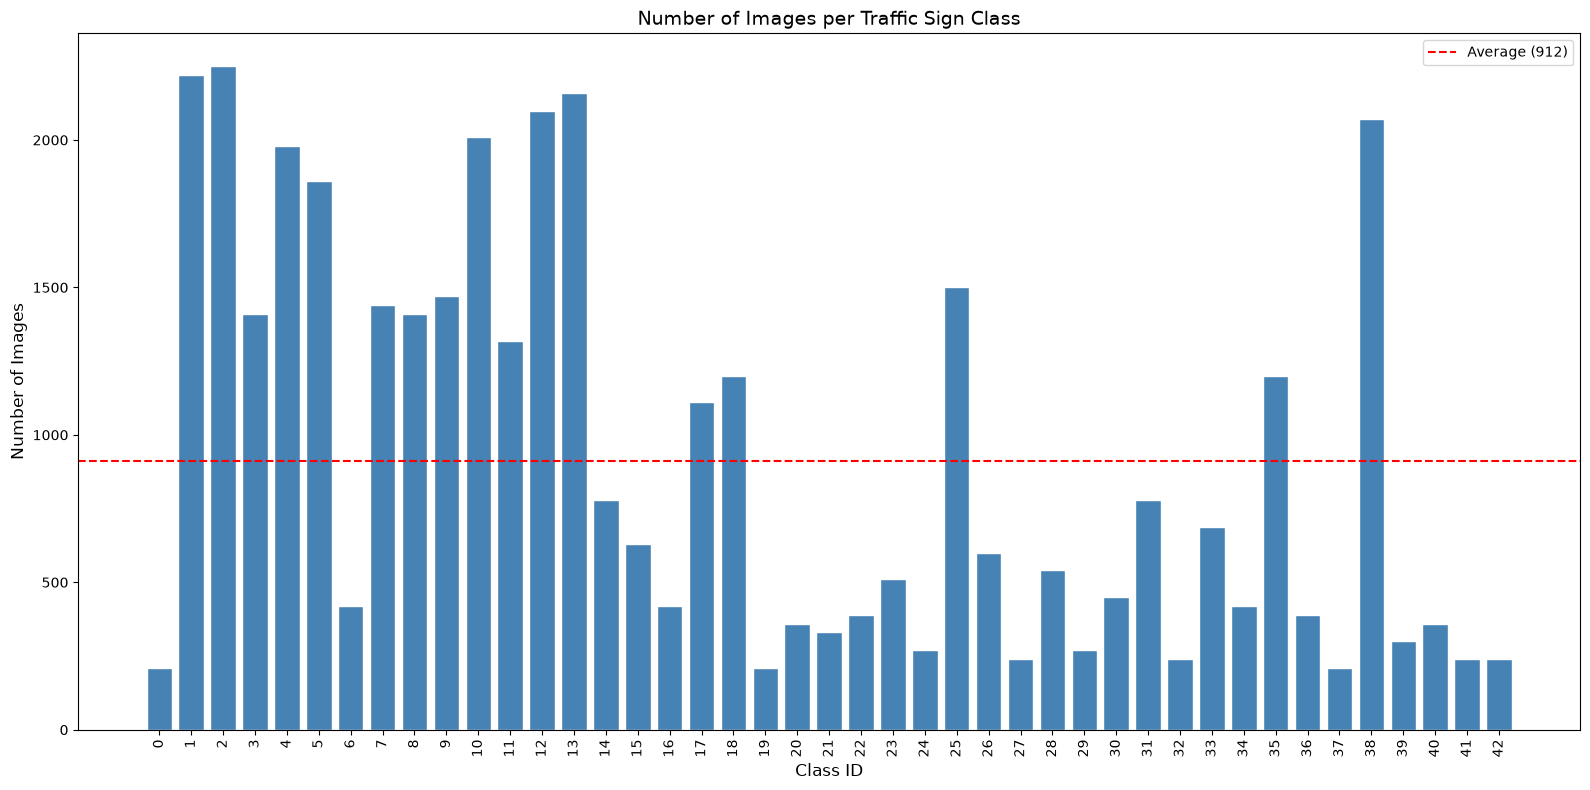

Class with most images: Speed limit (50km/h) (2250)
Class with least images: Speed limit (20km/h) (210)
Average images per class: 912
Imbalance ratio (max/min): 10.71


In [15]:
classes, counts = np.unique(y, return_counts=True)

df_dist = pd.DataFrame({
    'Class': classes,
    'Class_Name': [class_names[c] for c in classes],
    'Count': counts
})

df_dist_sorted = df_dist.sort_values(by='Count', ascending=False).reset_index(drop=True)
print(df_dist_sorted.to_string(index=False))

plt.figure(figsize=(16, 8))
plt.bar(classes, counts, color='steelblue', edgecolor='white')
plt.axhline(y=np.mean(counts), color='red', linestyle='--', label=f'Average ({np.mean(counts):.0f})')
plt.xticks(classes, rotation=90)
plt.title('Number of Images per Traffic Sign Class', fontsize=14)
plt.xlabel('Class ID', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig('outputs/01_class_distribution.png', dpi=150)
plt.show()

most_common_class = classes[np.argmax(counts)]
least_common_class = classes[np.argmin(counts)]
max_count = np.max(counts)
min_count = np.min(counts)
avg_count = np.mean(counts)

print(f"Class with most images: {class_names[most_common_class]} ({max_count})")
print(f"Class with least images: {class_names[least_common_class]} ({min_count})")
print(f"Average images per class: {avg_count:.0f}")
print(f"Imbalance ratio (max/min): {max_count/min_count:.2f}")

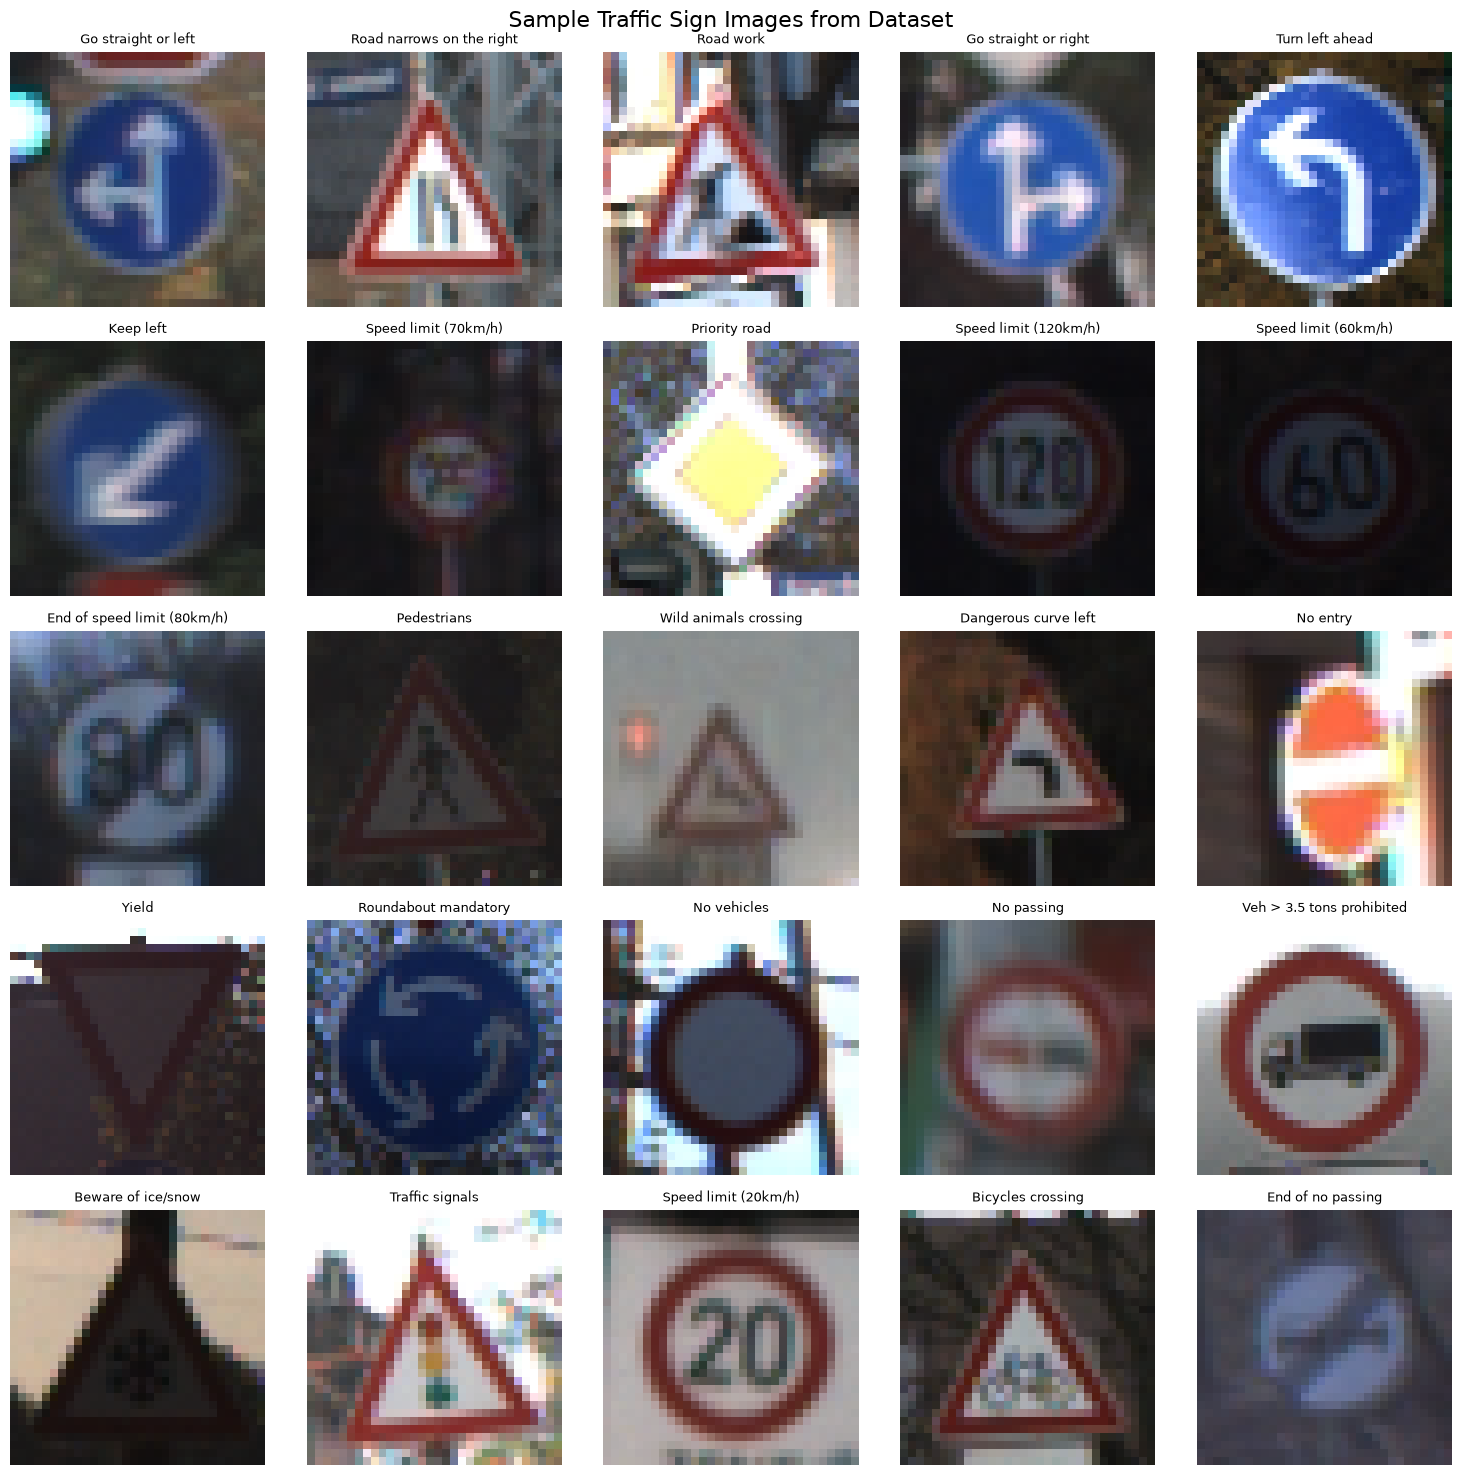

✅ Dataset exploration complete!


In [16]:
fig, axes = plt.subplots(5, 5, figsize=(15, 15))
fig.suptitle('Sample Traffic Sign Images from Dataset', fontsize=16)

unique_classes = np.unique(y)
selected_classes = np.random.choice(unique_classes, size=25, replace=len(unique_classes) < 25)

for i, ax in enumerate(axes.flat):
    cls = selected_classes[i]
    cls_indices = np.where(y == cls)[0]
    random_idx = np.random.choice(cls_indices)
    
    ax.imshow(X[random_idx])
    ax.set_title(class_names[cls], fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.savefig('outputs/02_sample_images.png', dpi=150)
plt.show()

print("✅ Dataset exploration complete!")